<a href="https://colab.research.google.com/github/jess22jess/SIMULACI-N-II/blob/main/Caminata_aleatoria_sobre_un_grafo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Caminata aleatoria sobre un grafo

Arcos Gutiérrez Jessica Beatriz

---

## Introducción

Sea una **buena cadena** una secuencia binaria de longitud $m$ en la que no aparecen dos $1$'s consecutivos. Nos interesa estimar el número esperado de $1$'s en una buena cadena, es decir,

$$
\mathbb{E}[\#1\text{'s}] = \sum_{s \in S} \pi(s)\,\text{unos}(s),
$$

donde $S$ es el conjunto de todas las buenas cadenas y $\pi$ es la distribución estacionaria de una caminata aleatoria definida sobre $S$.

La caminata se construye de la siguiente manera: dado un estado $s \in S$, se elige una de sus $m$ componentes al azar y:

- si la componente es $1$, se cambia a $0$ (la cadena resultante siempre es buena);
- si la componente es $0$, se cambia a $1$ **solo si** la cadena resultante sigue siendo buena; en caso contrario, el estado no cambia.

Este procedimiento define una cadena de Markov sobre $S$ cuya distribución estacionaria resulta ser uniforme, ya que todos los vértices del grafo asociado tienen peso total $m$. Bajo esta observación, el valor esperado se reduce a un promedio simple sobre $S$:

$$
\mathbb{E}[\#1\text{'s}] = \frac{1}{|S|}\sum_{s \in S} \text{unos}(s).
$$


Usamos networkx para crear, manipular y estudiar grafos.

In [5]:
import random
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

## Parámetros

Definimos la longitud de las cadenas binarias y el número total de pasos que realizará la caminata aleatoria.

- $m$: longitud de cada buena cadena.
- $\text{pasos}$: número de iteraciones de la caminata.

In [6]:
m = 4
pasos = 100000

El espacio de estados $S$ está formado por todas las cadenas binarias de longitud $m$ que no contienen la subcadena '11'. Estas se generan recorriendo los enteros de $0$ a $2^m - 1$ y conservando únicamente aquellos cuya representación binaria es una buena cadena.

In [7]:
estados = [format(i, f'0{m}b') for i in range(2**m) if '11' not in format(i, f'0{m}b')]

Con la función **caminata_aleatoria** implementamos el algoritmo de la introducción. En cada paso elige una posición al azar, invierte el bit correspondiente y acepta el cambio únicamente si la nueva cadena sigue siendo buena. El proceso se repite durante el número de pasos indicado y se lleva un registro del historial de estados y del promedio acumulado de $1$'s.

In [8]:
def caminata_aleatoria(estado_inicial, pasos, m):
    estado = estado_inicial
    historial = [estado]
    suma = 0
    for _ in range(pasos):
        i = random.randrange(m)
        v = list(estado)
        v[i] = '0' if v[i] == '1' else '1'
        v = ''.join(v)
        if '11' not in v:
            estado = v
        historial.append(estado)
        suma += estado.count('1')
    return historial, suma / pasos

Se ejecuta la caminata aleatoria partiendo de un estado inicial elegido al azar dentro de $S$. A partir del historial de estados visitados se estima el número esperado de $1$'s como el promedio de $1$'s sobre todos los pasos.

Este valor se compara con el **promedio teórico**, que bajo la distribución estacionaria uniforme está dado por

$$
\mathbb{E}[\#1\text{'s}] = \frac{1}{|S|}\sum_{s \in S} \text{unos}(s).
$$

In [9]:
historial, promedio_sim = caminata_aleatoria(random.choice(estados), pasos, m)
promedio_teo = sum(e.count('1') for e in estados) / len(estados)

print(f"Estados:   {estados}")
print(f"Promedio teórico:  {promedio_teo:.4f}")
print(f"Promedio simulado: {promedio_sim:.4f}")

Estados válidos:   ['0000', '0001', '0010', '0100', '0101', '1000', '1001', '1010']
Promedio teórico:  1.2500
Promedio simulado: 1.2545


Se construye el grafo asociado a la caminata usando networkx. Cada buena cadena es un nodo, y dos nodos se conectan mediante una arista si difieren en exactamente una componente y ambos son estados válidos.

In [10]:
G = nx.Graph()
G.add_nodes_from(estados)
for e in estados:
    for i in range(m):
        v = list(e)
        v[i] = '1' if v[i] == '0' else '0'
        v = ''.join(v)
        if v in estados and v != e:
            G.add_edge(e, v)

Se dibuja el grafo con nx.spring_layout para distribuir los nodos y nx.draw para mostrar las etiquetas de cada estado.

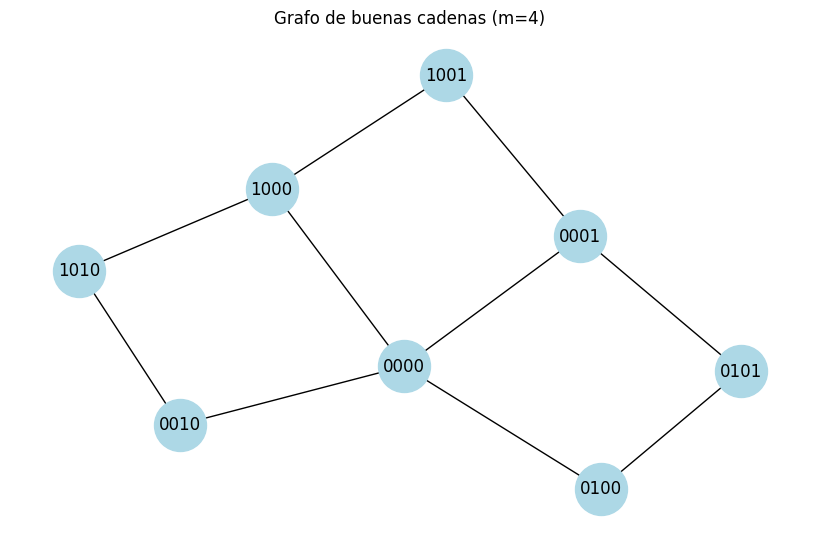

In [11]:
pos = nx.spring_layout(G, seed=1)
plt.figure(figsize=(8, 5))
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=1400)
plt.title(f"Grafo de buenas cadenas (m={m})")
plt.axis('off')
plt.show()

Para verificar que la caminata efectivamente muestrea la distribución estacionaria, se calcula el **promedio acumulado** de $1$'s a lo largo del historial:

$$
\bar{x}_n = \frac{1}{n}\sum_{k=1}^{n} \text{unos}(s_k),
$$

donde $s_k$ es el estado visitado en el paso $k$. Si la caminata es ergódica, $\bar{x}_n$ debe converger al valor teórico conforme $n \to \infty$.

In [12]:
acum = []
s = 0
for i, e in enumerate(historial):
    s += e.count('1')
    acum.append(s / (i + 1))

Se grafica el promedio acumulado en función del número de pasos y se compara contra el promedio teórico (línea roja discontinua).

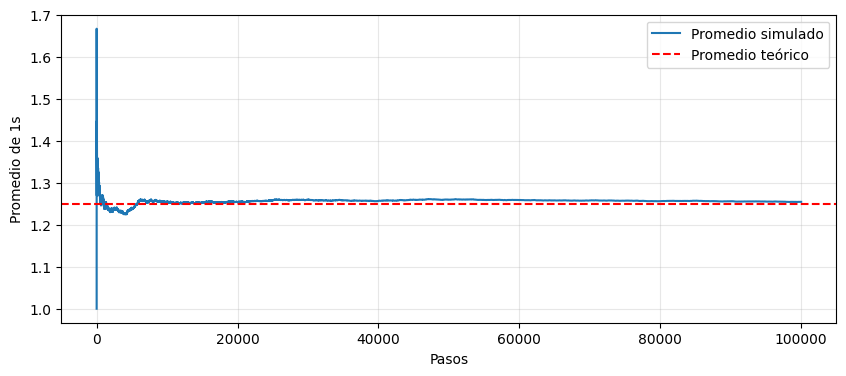

In [13]:
plt.figure(figsize=(10, 4))
plt.plot(acum, label='Promedio simulado')
plt.axhline(promedio_teo, color='r', ls='--', label='Promedio teórico')
plt.xlabel('Pasos')
plt.ylabel('Promedio de 1s')
plt.legend()
plt.grid(alpha=0.3)
plt.show()